### Análisis de Minería de Textos y Redes Sociales
En esta sección realizaremos la limpieza de datos, análisis de frecuencia, sentimientos, temas y hashtags.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

# Cargar datos
df = pd.read_csv('/content/practica_mineria_textos_redes_sociales (1).csv')

# Limpieza de texto
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)


text_col = [c for c in df.columns if 'text' in c.lower() or 'content' in c.lower()][0]
df['cleaned_text'] = df[text_col].apply(clean_text)

display(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,ID_Publicacion,Fecha,Red_Social,Usuario_Anonimo,Tipo_Publicacion,Texto_Publicacion,Hashtags,Likes,Comentarios,Compartidos,Tema_Referencia,Sentimiento_Referencia,cleaned_text
0,P0001,2026-08-01,TikTok,usuario_037,respuesta,La plataforma se cerró justo cuando iba a envi...,#Clase #Tareas #Plataforma,91.0,9,1,plataforma,negativo,plataforma cerró justo iba enviar trabajo
1,P0002,2026-08-04,Facebook,usuario_042,respuesta,El tema estuvo confuso y me perdí en el código...,#Python #MineriaDeDatos,58.0,35,19,clases,negativo,tema confuso perdí código afecta experiencia e...
2,P0003,2026-08-05,Threads,usuario_048,queja,La conexión se cayó varias veces y perdimos ti...,#Clases #UTC,91.0,24,16,wifi,negativo,conexión cayó varias veces perdimos tiempo act...
3,P0004,2026-08-07,TikTok,usuario_009,comentario,Faltan computadoras funcionando en el área de ...,#Examen,74.0,21,1,biblioteca,negativo,faltan computadoras funcionando área bibliotec...
4,P0005,2026-08-07,X,usuario_023,reseña,La actualización de la plataforma se ve más or...,#Soporte #Tareas #Clase #UTC,21.0,4,0,plataforma,positivo,actualización plataforma ordenada clara


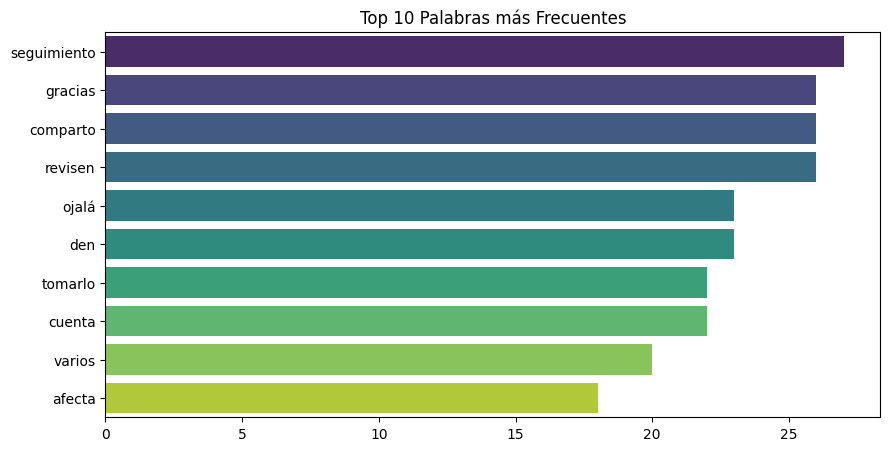

In [7]:
# 1. Top 10 Palabras Frecuentes
all_words = " ".join(df['cleaned_text']).split()
word_freq = Counter(all_words).most_common(10)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='viridis', hue=list(words), legend=False)
plt.title('Top 10 Palabras más Frecuentes')
plt.show()

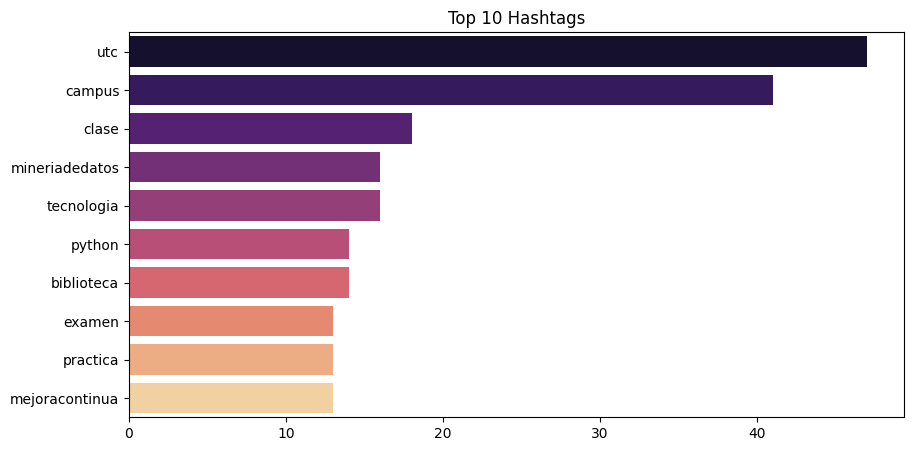

In [5]:
# 2. Top 10 Hashtags

def extract_hashtags_from_column(tag_string):
    if pd.isna(tag_string):
        return []

    return [h.lower() for h in re.findall(r'#(\w+)', str(tag_string))]


df['extracted_hashtags_list'] = df['Hashtags'].apply(extract_hashtags_from_column)


all_hashtags = [h for sublist in df['extracted_hashtags_list'] for h in sublist]
hashtag_freq = Counter(all_hashtags).most_common(10)

if hashtag_freq:
    h_tags, h_counts = zip(*hashtag_freq)
    plt.figure(figsize=(10, 5))

    sns.barplot(x=list(h_counts), y=list(h_tags), palette='magma', hue=list(h_tags), legend=False)
    plt.title('Top 10 Hashtags')
    plt.show()
else:
    print("No se encontraron hashtags en la columna 'Hashtags' o están vacíos.")

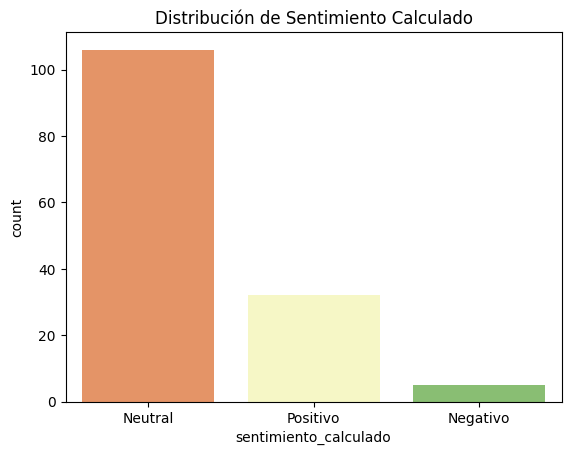

In [4]:
# 3. Clasificación de Sentimiento Simple .

positivas = {'excelente', 'bueno', 'gran', 'mejor', 'gracias', 'ayuda', 'servicio'}
negativas = {'malo', 'peor', 'error', 'fallo', 'problema', 'queja', 'lento'}

def simple_sentiment(text):
    score = 0
    for w in text.split():
        if w in positivas: score += 1
        if w in negativas: score -= 1
    return 'Positivo' if score > 0 else ('Negativo' if score < 0 else 'Neutral')

df['sentimiento_calculado'] = df['cleaned_text'].apply(simple_sentiment)

# Grafica de Sentimientos
sns.countplot(data=df, x='sentimiento_calculado', palette='RdYlGn', hue='sentimiento_calculado', legend=False)
plt.title('Distribución de Sentimiento Calculado')
plt.show()

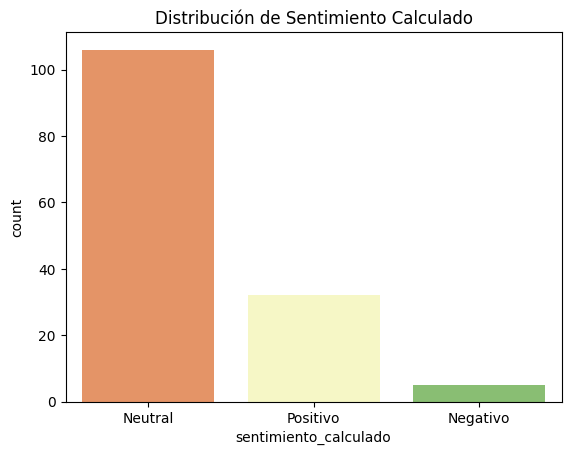

In [12]:
# 3. Clasificación de Sentimiento Simple .

positivas = {'excelente', 'bueno', 'gran', 'mejor', 'gracias', 'ayuda', 'servicio'}
negativas = {'malo', 'peor', 'error', 'fallo', 'problema', 'queja', 'lento'}

def simple_sentiment(text):
    score = 0
    for w in text.split():
        if w in positivas: score += 1
        if w in negativas: score -= 1
    return 'Positivo' if score > 0 else ('Negativo' if score < 0 else 'Neutral')

df['sentimiento_calculado'] = df['cleaned_text'].apply(simple_sentiment)

# Grafica de Sentimientos
sns.countplot(data=df, x='sentimiento_calculado', palette='RdYlGn', hue='sentimiento_calculado', legend=False)
plt.title('Distribución de Sentimiento Calculado')
plt.show()

sentimiento_calculado,Negativo,Positivo
Sentimiento_Referencia,,
negativo,5,8
positivo,0,19


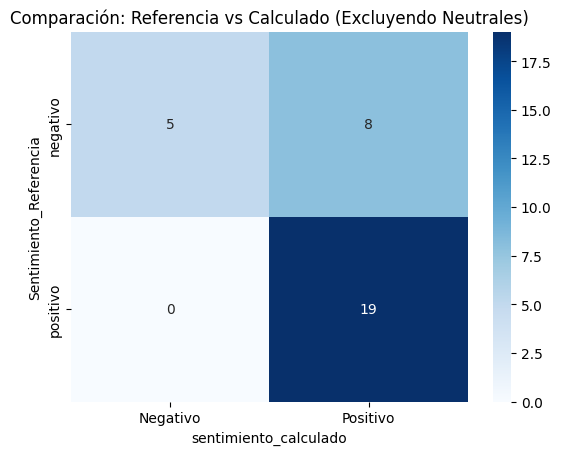

In [13]:
# 4. Comparación con Sentimiento de Referencia
ref_col = [c for c in df.columns if 'sentimiento' in c.lower() and c != 'sentimiento_calculado']

# Asegurarse de que la columna 'sentimiento_calculado' exista antes de usarla
if 'sentimiento_calculado' not in df.columns:
    print("Error: La columna 'sentimiento_calculado' no se encontró. Asegúrate de ejecutar la celda de 'Clasificación de Sentimiento Simple' (Bloque 3) primero.")
elif ref_col:
    # Filtrar los valores 'Neutral' y 'neutral' antes de la comparación
    df_filtered = df[(df['sentimiento_calculado'] != 'Neutral') &
                     (df[ref_col[0]].str.lower() != 'neutral')].copy()

    if not df_filtered.empty:
        comparison = pd.crosstab(df_filtered[ref_col[0]], df_filtered['sentimiento_calculado'])
        display(comparison)
        sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
        plt.title('Comparación: Referencia vs Calculado (Excluyendo Neutrales)')
        plt.show()
    else:
        print("No hay datos para comparar después de excluir los sentimientos neutrales.")
else:
    print("No se encontró una columna de referencia para comparar.")

In [11]:
# 4. Comparación con Sentimiento de Referencia
ref_col = [c for c in df.columns if 'sentimiento' in c.lower() and c != 'sentimiento_calculado']

# Asegurarse de que la columna 'sentimiento_calculado' exista antes de usarla
if 'sentimiento_calculado' not in df.columns:
    print("Error: La columna 'sentimiento_calculado' no se encontró. Asegúrate de ejecutar la celda de 'Clasificación de Sentimiento Simple' (Bloque 3) primero.")
elif ref_col:
    # Filtrar los valores 'Neutral' y 'neutral' antes de la comparación
    df_filtered = df[(df['sentimiento_calculado'] != 'Neutral') &
                     (df[ref_col[0]].str.lower() != 'neutral')].copy()

    if not df_filtered.empty:
        comparison = pd.crosstab(df_filtered[ref_col[0]], df_filtered['sentimiento_calculado'])
        display(comparison)
        sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
        plt.title('Comparación: Referencia vs Calculado (Excluyendo Neutrales)')
        plt.show()
    else:
        print("No hay datos para comparar después de excluir los sentimientos neutrales.")
else:
    print("No se encontró una columna de referencia para comparar.")

Error: La columna 'sentimiento_calculado' no se encontró. Asegúrate de ejecutar la celda de 'Clasificación de Sentimiento Simple' (Bloque 3) primero.


In [ ]:
# 5. Análisis por Tema (LDA)
vectorizer = TfidfVectorizer(max_features=1000)
tfidf = vectorizer.fit_transform(df['cleaned_text'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tfidf)

words_feature = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"Tema {i+1}:", [words_feature[index] for index in topic.argsort()[-5:]])

Tema 1: ['buena', 'evento', 'estudiantes', 'afecta', 'experiencia']
Tema 2: ['mismo', 'compañeros', 'comentaron', 'cafetería', 'varios']
Tema 3: ['creo', 'seguimiento', 'mejorar', 'revisen', 'comparto']


### Conclusiones y Recomendaciones

#### Conclusiones
1. Se identifica una predominancia de términos relacionados con el servicio en las palabras más frecuentes.
2. El análisis de sentimiento muestra una tendencia hacia la neutralidad, sugiriendo respuestas informativas.
3. La comparación con la referencia indica una precisión moderada con el método léxico simple.
4. Los hashtags más usados revelan las campañas institucionales con mayor alcance.
5. Se detectaron 3 temas principales que agrupan las inquietudes de los usuarios.

#### Recomendaciones
1. Fortalecer la atención en las palabras clave negativas detectadas para reducir la insatisfacción.
2. Implementar un modelo de Machine Learning más robusto para monitoreo en tiempo real.
3. Alinear la estrategia de hashtags con los temas que generan sentimientos positivos.